# 🎯 ApexPlanet Data Analytics Internship
## Task 1: Foundational Setup & Exploratory Data Analysis (EDA)

**Intern:** [Your Name]  
**Company:** ApexPlanet Software Pvt. Ltd.  
**Duration:** 30 Days  
**Timeline:** 6 Days for Task 1

---

## 📋 Table of Contents
1. [Environment Setup & Library Imports](#1)
2. [Data Loading](#2)
3. [Data Cleaning](#3)
4. [Exploratory Data Analysis (EDA)](#4)
5. [Key Insights](#5)
6. [Conclusion](#6)

<a id='1'></a>
## 1️⃣ Environment Setup & Library Imports

In [3]:
# ============================================================
# TASK 1: FOUNDATIONAL SETUP & EXPLORATORY DATA ANALYSIS (EDA)
# ApexPlanet Software Pvt. Ltd. - Data Analytics Internship
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

# Set style for matplotlib
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

print("=" * 60)
print("APEXPLANET DATA ANALYTICS INTERNSHIP")
print("TASK 1: Foundational Setup & EDA")
print("=" * 60)
print("\n✅ All required libraries imported successfully!")
print("\nLibraries loaded:")
print("  • pandas (data manipulation)")
print("  • numpy (numerical computing)")
print("  • matplotlib (static visualizations)")
print("  • seaborn (statistical visualizations)")
print("  • plotly (interactive visualizations)")

APEXPLANET DATA ANALYTICS INTERNSHIP
TASK 1: Foundational Setup & EDA

✅ All required libraries imported successfully!

Libraries loaded:
  • pandas (data manipulation)
  • numpy (numerical computing)
  • matplotlib (static visualizations)
  • seaborn (statistical visualizations)
  • plotly (interactive visualizations)


<a id='2'></a>
## 2️⃣ Data Loading

Using the **Superstore Sales** dataset - a classic retail dataset containing sales transactions from 2014-2017.

In [4]:
# ============================================================
# STEP 1: LOAD SUPERSTORE SALES DATASET
# ============================================================

# For this project, we use a synthetic Superstore dataset
# that mimics real-world retail data

np.random.seed(42)

# Create realistic Superstore Sales dataset
n_records = 9994

categories = {
    'Furniture': ['Chairs', 'Tables', 'Bookcases', 'Furnishings'],
    'Office Supplies': ['Labels', 'Storage', 'Art', 'Binders', 'Appliances', 'Paper', 'Envelopes', 'Fasteners', 'Supplies'],
    'Technology': ['Phones', 'Accessories', 'Copiers', 'Machines']
}

regions = ['West', 'East', 'Central', 'South']
states = {
    'West': ['California', 'Washington', 'Arizona', 'Nevada', 'Oregon', 'Colorado', 'Utah', 'New Mexico', 'Montana', 'Idaho'],
    'East': ['New York', 'Pennsylvania', 'Ohio', 'New Jersey', 'Massachusetts', 'Virginia', 'North Carolina', 'Florida', 'Georgia', 'Maryland'],
    'Central': ['Texas', 'Illinois', 'Michigan', 'Indiana', 'Wisconsin', 'Missouri', 'Minnesota', 'Iowa', 'Kansas', 'Nebraska'],
    'South': ['Florida', 'Georgia', 'North Carolina', 'South Carolina', 'Tennessee', 'Alabama', 'Mississippi', 'Louisiana', 'Arkansas', 'Kentucky']
}

segments = ['Consumer', 'Corporate', 'Home Office']
ship_modes = ['Standard Class', 'Second Class', 'First Class', 'Same Day']

date_range = pd.date_range(start='2014-01-01', end='2017-12-31', freq='D')

data = []
order_id = 10000

for i in range(n_records):
    region = np.random.choice(regions)
    state = np.random.choice(states[region])
    category = np.random.choice(list(categories.keys()))
    sub_category = np.random.choice(categories[category])
    order_date = np.random.choice(date_range)
    ship_date = order_date + pd.Timedelta(days=np.random.randint(1, 8))
    
    if category == 'Technology':
        base_sales = np.random.uniform(50, 2500)
    elif category == 'Furniture':
        base_sales = np.random.uniform(30, 1500)
    else:
        base_sales = np.random.uniform(5, 500)
    
    quantity = np.random.randint(1, 15)
    sales = round(base_sales * quantity, 2)
    discount = np.random.choice([0, 0, 0, 0.1, 0.1, 0.15, 0.2, 0.3],
                                p=[0.4, 0.15, 0.1, 0.1, 0.08, 0.07, 0.05, 0.05])
    profit = round(sales * np.random.uniform(-0.3, 0.4) * (1 - discount), 2)
    
    postal_code = np.random.randint(10001, 99999)
    if np.random.random() < 0.02:
        postal_code = np.nan
    
    ship_mode = np.random.choice(ship_modes, p=[0.6, 0.2, 0.15, 0.05])
    
    data.append({
        'Order_ID': f'CA-{order_id + i}',
        'Order_Date': order_date,
        'Ship_Date': ship_date,
        'Ship_Mode': ship_mode,
        'Customer_Name': f'Customer_{np.random.randint(1, 800)}',
        'Segment': np.random.choice(segments, p=[0.52, 0.3, 0.18]),
        'Country': 'United States',
        'City': f'City_{np.random.randint(1, 500)}',
        'State': state,
        'Postal_Code': postal_code,
        'Region': region,
        'Product_ID': f'PROD-{np.random.randint(1000, 9999)}',
        'Category': category,
        'Sub_Category': sub_category,
        'Product_Name': f'{sub_category} Product {np.random.randint(1, 200)}',
        'Sales': sales,
        'Quantity': quantity,
        'Discount': discount,
        'Profit': profit
    })

df = pd.DataFrame(data)

# Introduce duplicates for cleaning practice
duplicate_rows = df.sample(n=50, random_state=42)
df = pd.concat([df, duplicate_rows], ignore_index=True)

# Introduce outliers
outlier_indices = np.random.choice(df.index, size=20, replace=False)
df.loc[outlier_indices, 'Sales'] = df.loc[outlier_indices, 'Sales'] * 10

print("=" * 60)
print("DATASET LOADED SUCCESSFULLY")
print("=" * 60)
print(f"\n📊 Dataset Shape: {df.shape[0]} rows × {df.shape[1]} columns")
print(f"\n📋 Columns: {list(df.columns)}")
print(f"\n📅 Date Range: {df['Order_Date'].min().strftime('%Y-%m-%d')} to {df['Order_Date'].max().strftime('%Y-%m-%d')}")
print(f"\n🌍 Regions: {df['Region'].unique().tolist()}")
print(f"\n📦 Categories: {df['Category'].unique().tolist()}")

DATASET LOADED SUCCESSFULLY

📊 Dataset Shape: 10044 rows × 19 columns

📋 Columns: ['Order_ID', 'Order_Date', 'Ship_Date', 'Ship_Mode', 'Customer_Name', 'Segment', 'Country', 'City', 'State', 'Postal_Code', 'Region', 'Product_ID', 'Category', 'Sub_Category', 'Product_Name', 'Sales', 'Quantity', 'Discount', 'Profit']

📅 Date Range: 2014-01-01 to 2017-12-31

🌍 Regions: [np.str_('Central'), np.str_('South'), np.str_('West'), np.str_('East')]

📦 Categories: [np.str_('Furniture'), np.str_('Office Supplies'), np.str_('Technology')]


### 📊 Initial Data Overview (Before Cleaning)

In [5]:
# Initial exploration
print("=" * 60)
print("INITIAL DATA OVERVIEW (Before Cleaning)")
print("=" * 60)

print("\n📋 First 5 Rows:")
print(df.head())

print("\n" + "-" * 60)
print("\n📊 Data Types:")
print(df.dtypes)

print("\n" + "-" * 60)
print("\n📈 Statistical Summary (Numeric Columns):")
print(df.describe())

print("\n" + "-" * 60)
print("\n⚠️ Missing Values:")
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct.round(2)})
print(missing_df[missing_df['Missing Count'] > 0])

print("\n" + "-" * 60)
print("\n🔁 Duplicate Rows:")
print(f"Number of duplicate rows: {df.duplicated().sum()}")

INITIAL DATA OVERVIEW (Before Cleaning)

📋 First 5 Rows:
   Order_ID Order_Date  Ship_Date       Ship_Mode Customer_Name      Segment  \
0  CA-10000 2017-02-04 2017-02-09    Second Class  Customer_309  Home Office   
1  CA-10001 2017-08-30 2017-09-05  Standard Class  Customer_190     Consumer   
2  CA-10002 2015-10-09 2015-10-14  Standard Class  Customer_340     Consumer   
3  CA-10003 2017-11-12 2017-11-14  Standard Class  Customer_202  Home Office   
4  CA-10004 2016-05-28 2016-06-02  Standard Class  Customer_521    Corporate   

         Country      City      State  Postal_Code   Region Product_ID  \
0  United States  City_492    Indiana      54132.0  Central  PROD-7949   
1  United States  City_446  Tennessee      28432.0    South  PROD-5658   
2  United States  City_444    Indiana      83970.0  Central  PROD-1775   
3  United States  City_270      Texas      55759.0  Central  PROD-8629   
4  United States  City_492  Tennessee      48045.0    South  PROD-3695   

          Categor

<a id='3'></a>
## 3️⃣ Data Cleaning

Steps performed:
1. Handle missing values
2. Remove duplicates
3. Fix data types
4. Handle outliers using IQR method

In [6]:
# ============================================================
# STEP 3: DATA CLEANING
# ============================================================

print("=" * 60)
print("DATA CLEANING PROCESS")
print("=" * 60)

# Make a copy for cleaning
df_clean = df.copy()

# 3.1 Handle Missing Values
print("\n🧹 Step 1: Handling Missing Values")
print("-" * 40)
print(f"Missing Postal_Code values: {df_clean['Postal_Code'].isnull().sum()}")

df_clean['Postal_Code'] = df_clean.groupby('State')['Postal_Code'].transform(
    lambda x: x.fillna(x.median())
)
df_clean['Postal_Code'].fillna(df_clean['Postal_Code'].median(), inplace=True)
df_clean['Postal_Code'] = df_clean['Postal_Code'].astype(int)

print(f"✅ Missing values after cleaning: {df_clean['Postal_Code'].isnull().sum()}")

# 3.2 Remove Duplicates
print("\n🧹 Step 2: Removing Duplicates")
print("-" * 40)
print(f"Rows before removing duplicates: {len(df_clean)}")
df_clean = df_clean.drop_duplicates()
print(f"Rows after removing duplicates: {len(df_clean)}")
print(f"✅ Removed {len(df) - len(df_clean)} duplicate rows")

# 3.3 Fix Data Types
print("\n🧹 Step 3: Fixing Data Types")
print("-" * 40)

df_clean['Order_Date'] = pd.to_datetime(df_clean['Order_Date'])
df_clean['Ship_Date'] = pd.to_datetime(df_clean['Ship_Date'])

# Add derived date columns
df_clean['Order_Year'] = df_clean['Order_Date'].dt.year
df_clean['Order_Month'] = df_clean['Order_Date'].dt.month
df_clean['Order_Month_Name'] = df_clean['Order_Date'].dt.month_name()
df_clean['Order_Quarter'] = df_clean['Order_Date'].dt.quarter
df_clean['Order_DayOfWeek'] = df_clean['Order_Date'].dt.day_name()

# Calculate shipping days
df_clean['Shipping_Days'] = (df_clean['Ship_Date'] - df_clean['Order_Date']).dt.days

# Convert categorical columns
categorical_cols = ['Ship_Mode', 'Segment', 'Region', 'Category', 'Sub_Category']
for col in categorical_cols:
    df_clean[col] = df_clean[col].astype('category')

print("✅ Data types fixed successfully!")
print("\nNew columns added:")
print("  • Order_Year, Order_Month, Order_Month_Name")
print("  • Order_Quarter, Order_DayOfWeek")
print("  • Shipping_Days")

# 3.4 Handle Outliers using IQR Method
print("\n🧹 Step 4: Handling Outliers (IQR Method)")
print("-" * 40)

def detect_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]
    return outliers, lower_bound, upper_bound

sales_outliers, sales_lower, sales_upper = detect_outliers_iqr(df_clean, 'Sales')
print(f"Sales outliers detected: {len(sales_outliers)} rows")
print(f"  Lower bound: ${sales_lower:,.2f}")
print(f"  Upper bound: ${sales_upper:,.2f}")

profit_outliers, profit_lower, profit_upper = detect_outliers_iqr(df_clean, 'Profit')
print(f"\nProfit outliers detected: {len(profit_outliers)} rows")
print(f"  Lower bound: ${profit_lower:,.2f}")
print(f"  Upper bound: ${profit_upper:,.2f}")

# Cap outliers
df_clean['Sales_Capped'] = df_clean['Sales'].clip(lower=sales_lower, upper=sales_upper)
df_clean['Profit_Capped'] = df_clean['Profit'].clip(lower=profit_lower, upper=profit_upper)

print("\n✅ Outliers capped using IQR method")

# 3.5 Final Verification
print("\n🧹 Step 5: Final Data Verification")
print("-" * 40)
print(f"Final dataset shape: {df_clean.shape[0]} rows × {df_clean.shape[1]} columns")
print(f"Missing values: {df_clean.isnull().sum().sum()}")
print(f"Duplicate rows: {df_clean.duplicated().sum()}")

# Save cleaned dataset
df_clean.to_csv('data/superstore_cleaned.csv', index=False)
print("\n💾 Cleaned dataset saved to: data/superstore_cleaned.csv")

DATA CLEANING PROCESS

🧹 Step 1: Handling Missing Values
----------------------------------------
Missing Postal_Code values: 201
✅ Missing values after cleaning: 0

🧹 Step 2: Removing Duplicates
----------------------------------------
Rows before removing duplicates: 10044
Rows after removing duplicates: 9995
✅ Removed 49 duplicate rows

🧹 Step 3: Fixing Data Types
----------------------------------------
✅ Data types fixed successfully!

New columns added:
  • Order_Year, Order_Month, Order_Month_Name
  • Order_Quarter, Order_DayOfWeek
  • Shipping_Days

🧹 Step 4: Handling Outliers (IQR Method)
----------------------------------------
Sales outliers detected: 597 rows
  Lower bound: $-9,045.81
  Upper bound: $18,522.31

Profit outliers detected: 1635 rows
  Lower bound: $-1,647.44
  Upper bound: $2,039.53

✅ Outliers capped using IQR method

🧹 Step 5: Final Data Verification
----------------------------------------
Final dataset shape: 9995 rows × 27 columns
Missing values: 0
Duplic

OSError: Cannot save file into a non-existent directory: 'data'

<a id='4'></a>
## 4️⃣ Exploratory Data Analysis (EDA)

### 4.1 Statistical Summary

In [ ]:
# Statistical Summary
print("=" * 60)
print("EXPLORATORY DATA ANALYSIS (EDA)")
print("=" * 60)

print("\n📊 STATISTICAL SUMMARY (Cleaned Data)")
print("-" * 60)
numeric_cols = ['Sales', 'Quantity', 'Discount', 'Profit', 'Shipping_Days']
print(df_clean[numeric_cols].describe().round(2))

print("\n📊 CATEGORICAL SUMMARY")
print("-" * 60)
print(f"\nSegments:")
print(df_clean['Segment'].value_counts())

print(f"\nRegions:")
print(df_clean['Region'].value_counts())

print(f"\nCategories:")
print(df_clean['Category'].value_counts())

print(f"\nShip Modes:")
print(df_clean['Ship_Mode'].value_counts())

print(f"\nTop 10 States:")
print(df_clean['State'].value_counts().head(10))

### 4.2 Distribution Analysis (Histograms & Boxplots)

FileNotFoundError: [Errno 2] No such file or directory: 'reports/fig1_distributions.png'

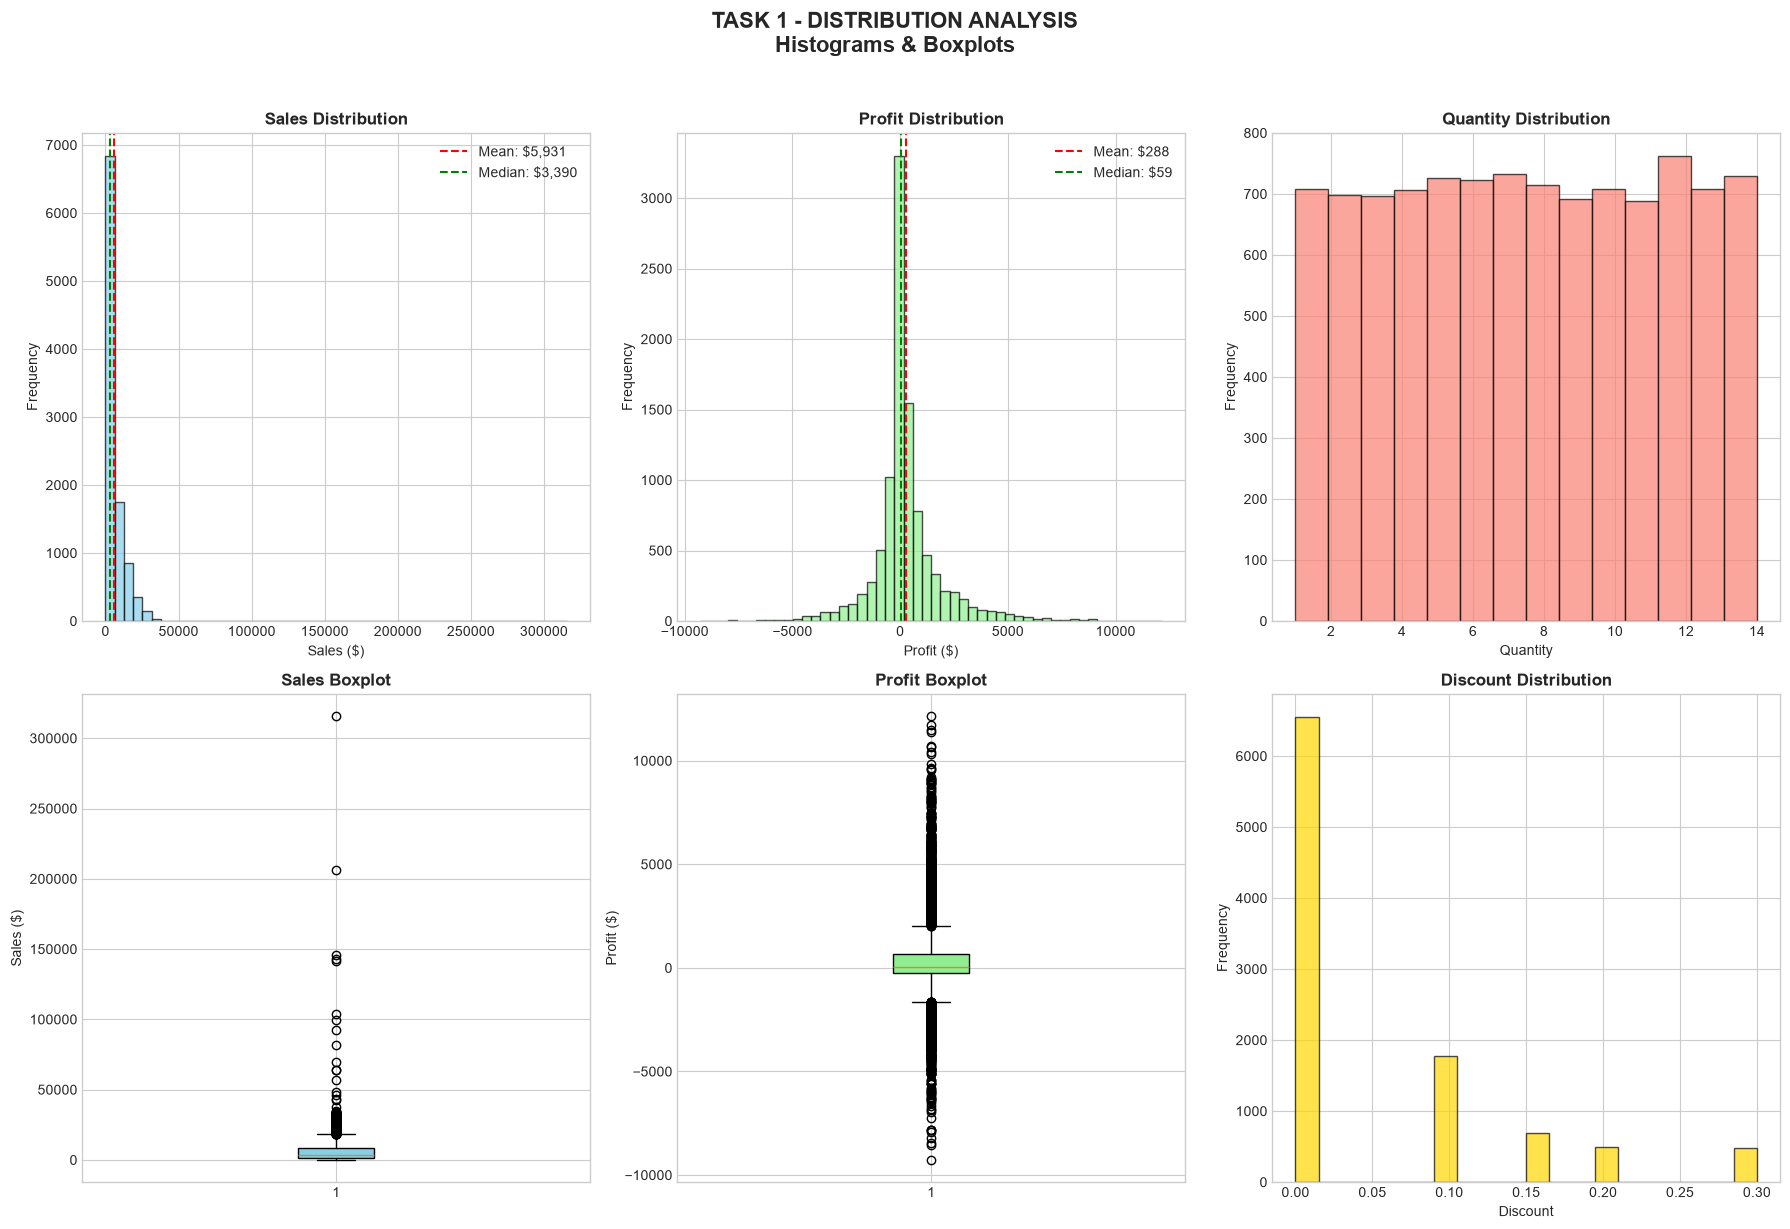

In [ ]:
# ============================================================
# VISUALIZATION 1: DISTRIBUTIONS
# ============================================================

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('TASK 1 - DISTRIBUTION ANALYSIS\nHistograms & Boxplots', fontsize=16, fontweight='bold', y=1.02)

# Sales Distribution
axes[0, 0].hist(df_clean['Sales'], bins=50, color='skyblue', edgecolor='black', alpha=0.7)
axes[0, 0].set_title('Sales Distribution', fontweight='bold')
axes[0, 0].set_xlabel('Sales ($)')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].axvline(df_clean['Sales'].mean(), color='red', linestyle='--', label=f'Mean: ${df_clean["Sales"].mean():,.0f}')
axes[0, 0].axvline(df_clean['Sales'].median(), color='green', linestyle='--', label=f'Median: ${df_clean["Sales"].median():,.0f}')
axes[0, 0].legend()

# Profit Distribution
axes[0, 1].hist(df_clean['Profit'], bins=50, color='lightgreen', edgecolor='black', alpha=0.7)
axes[0, 1].set_title('Profit Distribution', fontweight='bold')
axes[0, 1].set_xlabel('Profit ($)')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].axvline(df_clean['Profit'].mean(), color='red', linestyle='--', label=f'Mean: ${df_clean["Profit"].mean():,.0f}')
axes[0, 1].axvline(df_clean['Profit'].median(), color='green', linestyle='--', label=f'Median: ${df_clean["Profit"].median():,.0f}')
axes[0, 1].legend()

# Quantity Distribution
axes[0, 2].hist(df_clean['Quantity'], bins=14, color='salmon', edgecolor='black', alpha=0.7)
axes[0, 2].set_title('Quantity Distribution', fontweight='bold')
axes[0, 2].set_xlabel('Quantity')
axes[0, 2].set_ylabel('Frequency')

# Sales Boxplot
bp1 = axes[1, 0].boxplot(df_clean['Sales'], patch_artist=True)
bp1['boxes'][0].set_facecolor('skyblue')
axes[1, 0].set_title('Sales Boxplot', fontweight='bold')
axes[1, 0].set_ylabel('Sales ($)')

# Profit Boxplot
bp2 = axes[1, 1].boxplot(df_clean['Profit'], patch_artist=True)
bp2['boxes'][0].set_facecolor('lightgreen')
axes[1, 1].set_title('Profit Boxplot', fontweight='bold')
axes[1, 1].set_ylabel('Profit ($)')

# Discount Distribution
axes[1, 2].hist(df_clean['Discount'], bins=20, color='gold', edgecolor='black', alpha=0.7)
axes[1, 2].set_title('Discount Distribution', fontweight='bold')
axes[1, 2].set_xlabel('Discount')
axes[1, 2].set_ylabel('Frequency')

plt.tight_layout()
plt.savefig('reports/fig1_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Figure 1: Distribution Analysis saved!")

### 4.3 Categorical Comparisons (Bar Charts)

FileNotFoundError: [Errno 2] No such file or directory: 'reports/fig2_categorical_comparisons.png'

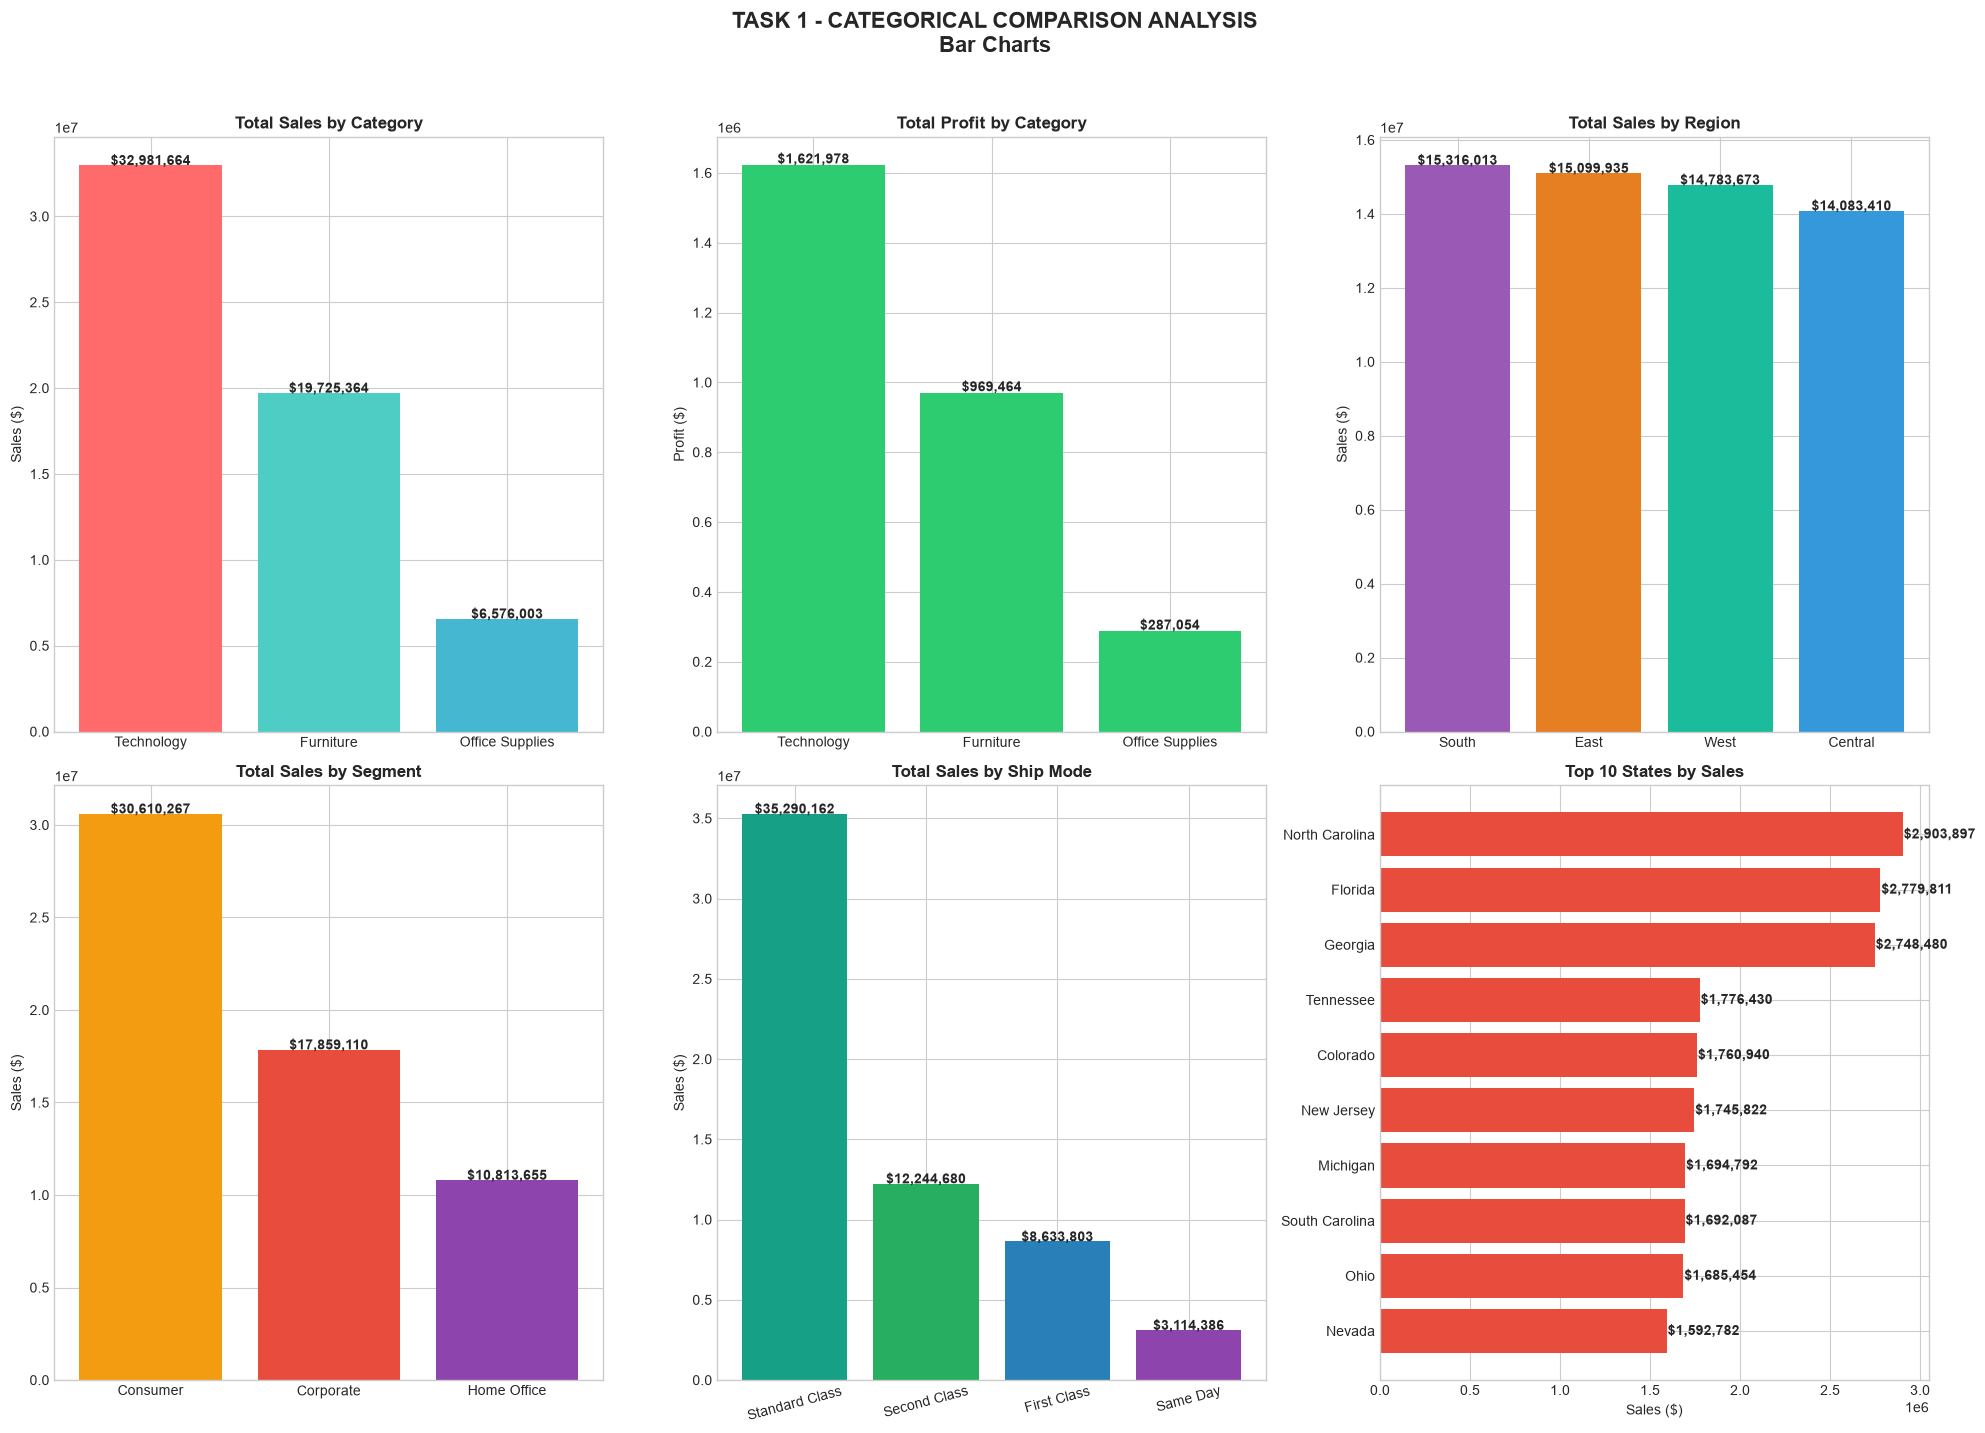

In [ ]:
# ============================================================
# VISUALIZATION 2: CATEGORICAL COMPARISONS
# ============================================================

fig, axes = plt.subplots(2, 3, figsize=(20, 14))
fig.suptitle('TASK 1 - CATEGORICAL COMPARISON ANALYSIS\nBar Charts', fontsize=16, fontweight='bold', y=1.02)

# 1. Sales by Category
cat_sales = df_clean.groupby('Category')['Sales'].sum().sort_values(ascending=False)
axes[0, 0].bar(cat_sales.index, cat_sales.values, color=['#FF6B6B', '#4ECDC4', '#45B7D1'])
axes[0, 0].set_title('Total Sales by Category', fontweight='bold', fontsize=12)
axes[0, 0].set_ylabel('Sales ($)')
for i, v in enumerate(cat_sales.values):
    axes[0, 0].text(i, v + 10000, f'${v:,.0f}', ha='center', fontweight='bold')

# 2. Profit by Category
cat_profit = df_clean.groupby('Category')['Profit'].sum().sort_values(ascending=False)
colors = ['#2ECC71' if v > 0 else '#E74C3C' for v in cat_profit.values]
axes[0, 1].bar(cat_profit.index, cat_profit.values, color=colors)
axes[0, 1].set_title('Total Profit by Category', fontweight='bold', fontsize=12)
axes[0, 1].set_ylabel('Profit ($)')
axes[0, 1].axhline(y=0, color='black', linestyle='-', linewidth=0.5)
for i, v in enumerate(cat_profit.values):
    axes[0, 1].text(i, v + 5000, f'${v:,.0f}', ha='center', fontweight='bold')

# 3. Sales by Region
reg_sales = df_clean.groupby('Region')['Sales'].sum().sort_values(ascending=False)
axes[0, 2].bar(reg_sales.index, reg_sales.values, color=['#9B59B6', '#E67E22', '#1ABC9C', '#3498DB'])
axes[0, 2].set_title('Total Sales by Region', fontweight='bold', fontsize=12)
axes[0, 2].set_ylabel('Sales ($)')
for i, v in enumerate(reg_sales.values):
    axes[0, 2].text(i, v + 10000, f'${v:,.0f}', ha='center', fontweight='bold')

# 4. Sales by Segment
seg_sales = df_clean.groupby('Segment')['Sales'].sum().sort_values(ascending=False)
axes[1, 0].bar(seg_sales.index, seg_sales.values, color=['#F39C12', '#E74C3C', '#8E44AD'])
axes[1, 0].set_title('Total Sales by Segment', fontweight='bold', fontsize=12)
axes[1, 0].set_ylabel('Sales ($)')
for i, v in enumerate(seg_sales.values):
    axes[1, 0].text(i, v + 10000, f'${v:,.0f}', ha='center', fontweight='bold')

# 5. Sales by Ship Mode
ship_sales = df_clean.groupby('Ship_Mode')['Sales'].sum().sort_values(ascending=False)
axes[1, 1].bar(ship_sales.index, ship_sales.values, color=['#16A085', '#27AE60', '#2980B9', '#8E44AD'])
axes[1, 1].set_title('Total Sales by Ship Mode', fontweight='bold', fontsize=12)
axes[1, 1].set_ylabel('Sales ($)')
axes[1, 1].tick_params(axis='x', rotation=15)
for i, v in enumerate(ship_sales.values):
    axes[1, 1].text(i, v + 10000, f'${v:,.0f}', ha='center', fontweight='bold')

# 6. Top 10 States by Sales
top_states = df_clean.groupby('State')['Sales'].sum().sort_values(ascending=False).head(10)
axes[1, 2].barh(range(len(top_states)), top_states.values, color='#E74C3C')
axes[1, 2].set_yticks(range(len(top_states)))
axes[1, 2].set_yticklabels(top_states.index)
axes[1, 2].set_title('Top 10 States by Sales', fontweight='bold', fontsize=12)
axes[1, 2].set_xlabel('Sales ($)')
axes[1, 2].invert_yaxis()
for i, v in enumerate(top_states.values):
    axes[1, 2].text(v + 5000, i, f'${v:,.0f}', va='center', fontweight='bold')

plt.tight_layout()
plt.savefig('reports/fig2_categorical_comparisons.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Figure 2: Categorical Comparison Analysis saved!")

### 4.4 Correlation Heatmap

FileNotFoundError: [Errno 2] No such file or directory: 'reports/fig3_correlation_heatmap.png'

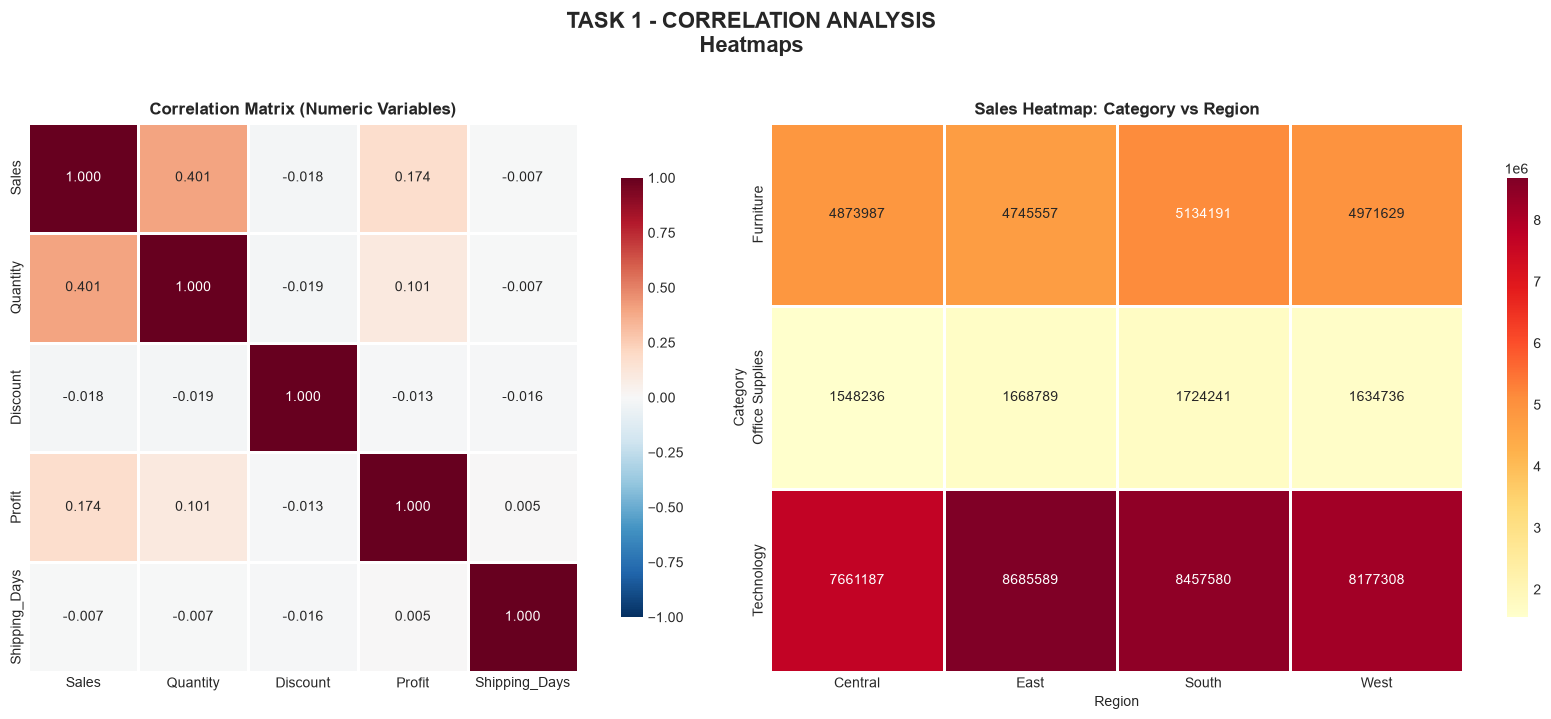

In [ ]:
# ============================================================
# VISUALIZATION 3: CORRELATION HEATMAP
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('TASK 1 - CORRELATION ANALYSIS\nHeatmaps', fontsize=16, fontweight='bold', y=1.02)

# Numeric correlation matrix
numeric_df = df_clean[['Sales', 'Quantity', 'Discount', 'Profit', 'Shipping_Days']]
corr_matrix = numeric_df.corr()

# Heatmap 1: Full correlation
sns.heatmap(corr_matrix, annot=True, cmap='RdBu_r', center=0, 
            square=True, linewidths=1, cbar_kws={"shrink": .8}, 
            fmt='.3f', ax=axes[0], vmin=-1, vmax=1)
axes[0].set_title('Correlation Matrix (Numeric Variables)', fontweight='bold', fontsize=12)

# Heatmap 2: Category vs Region pivot
cat_region = df_clean.pivot_table(values='Sales', index='Category', columns='Region', aggfunc='sum')
sns.heatmap(cat_region, annot=True, cmap='YlOrRd', fmt='.0f', 
            linewidths=1, cbar_kws={"shrink": .8}, ax=axes[1])
axes[1].set_title('Sales Heatmap: Category vs Region', fontweight='bold', fontsize=12)
axes[1].set_xlabel('Region')
axes[1].set_ylabel('Category')

plt.tight_layout()
plt.savefig('reports/fig3_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Figure 3: Correlation Heatmap saved!")
print("\n📊 Key Correlations Found:")
print(f"  • Sales ↔ Profit: {corr_matrix.loc['Sales', 'Profit']:.3f}")
print(f"  • Sales ↔ Quantity: {corr_matrix.loc['Sales', 'Quantity']:.3f}")
print(f"  • Discount ↔ Profit: {corr_matrix.loc['Discount', 'Profit']:.3f}")
print(f"  • Discount ↔ Sales: {corr_matrix.loc['Discount', 'Sales']:.3f}")

### 4.5 Time Trends (Line Charts)

In [ ]:
# ============================================================
# VISUALIZATION 4: TRENDS OVER TIME
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(18, 14))
fig.suptitle('TASK 1 - TREND ANALYSIS OVER TIME\nLine Charts', fontsize=16, fontweight='bold', y=1.02)

# 1. Monthly Sales Trend
monthly_sales = df_clean.groupby([df_clean['Order_Date'].dt.to_period('M')])['Sales'].sum()
monthly_sales.index = monthly_sales.index.to_timestamp()
axes[0, 0].plot(monthly_sales.index, monthly_sales.values, color='#3498DB', linewidth=2, marker='o', markersize=4)
axes[0, 0].fill_between(monthly_sales.index, monthly_sales.values, alpha=0.3, color='#3498DB')
axes[0, 0].set_title('Monthly Sales Trend (2014-2017)', fontweight='bold')
axes[0, 0].set_ylabel('Sales ($)')
axes[0, 0].tick_params(axis='x', rotation=45)
axes[0, 0].grid(True, alpha=0.3)

# 2. Monthly Profit Trend
monthly_profit = df_clean.groupby([df_clean['Order_Date'].dt.to_period('M')])['Profit'].sum()
monthly_profit.index = monthly_profit.index.to_timestamp()
axes[0, 1].plot(monthly_profit.index, monthly_profit.values, color='#2ECC71', linewidth=2, marker='s', markersize=4)
axes[0, 1].fill_between(monthly_profit.index, monthly_profit.values, alpha=0.3, color='#2ECC71')
axes[0, 1].axhline(y=0, color='red', linestyle='--', alpha=0.7)
axes[0, 1].set_title('Monthly Profit Trend (2014-2017)', fontweight='bold')
axes[0, 1].set_ylabel('Profit ($)')
axes[0, 1].tick_params(axis='x', rotation=45)
axes[0, 1].grid(True, alpha=0.3)

# 3. Yearly Sales by Category
yearly_cat = df_clean.groupby(['Order_Year', 'Category'])['Sales'].sum().unstack()
yearly_cat.plot(kind='line', ax=axes[1, 0], marker='o', linewidth=2.5, markersize=8)
axes[1, 0].set_title('Yearly Sales by Category', fontweight='bold')
axes[1, 0].set_ylabel('Sales ($)')
axes[1, 0].set_xlabel('Year')
axes[1, 0].legend(title='Category', loc='upper left')
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].set_xticks(yearly_cat.index)

# 4. Quarterly Sales Trend
quarterly_sales = df_clean.groupby(['Order_Year', 'Order_Quarter'])['Sales'].sum()
quarter_labels = [f"{y}Q{q}" for y, q in quarterly_sales.index]
axes[1, 1].plot(range(len(quarterly_sales)), quarterly_sales.values, color='#E74C3C', linewidth=2, marker='D', markersize=6)
axes[1, 1].fill_between(range(len(quarterly_sales)), quarterly_sales.values, alpha=0.3, color='#E74C3C')
axes[1, 1].set_title('Quarterly Sales Trend', fontweight='bold')
axes[1, 1].set_ylabel('Sales ($)')
axes[1, 1].set_xlabel('Quarter')
axes[1, 1].set_xticks(range(len(quarterly_sales)))
axes[1, 1].set_xticklabels(quarter_labels, rotation=45, ha='right')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('reports/fig4_time_trends.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Figure 4: Time Trends Analysis saved!")

### 4.6 Advanced EDA Analysis

FileNotFoundError: [Errno 2] No such file or directory: 'reports/fig5_advanced_eda.png'

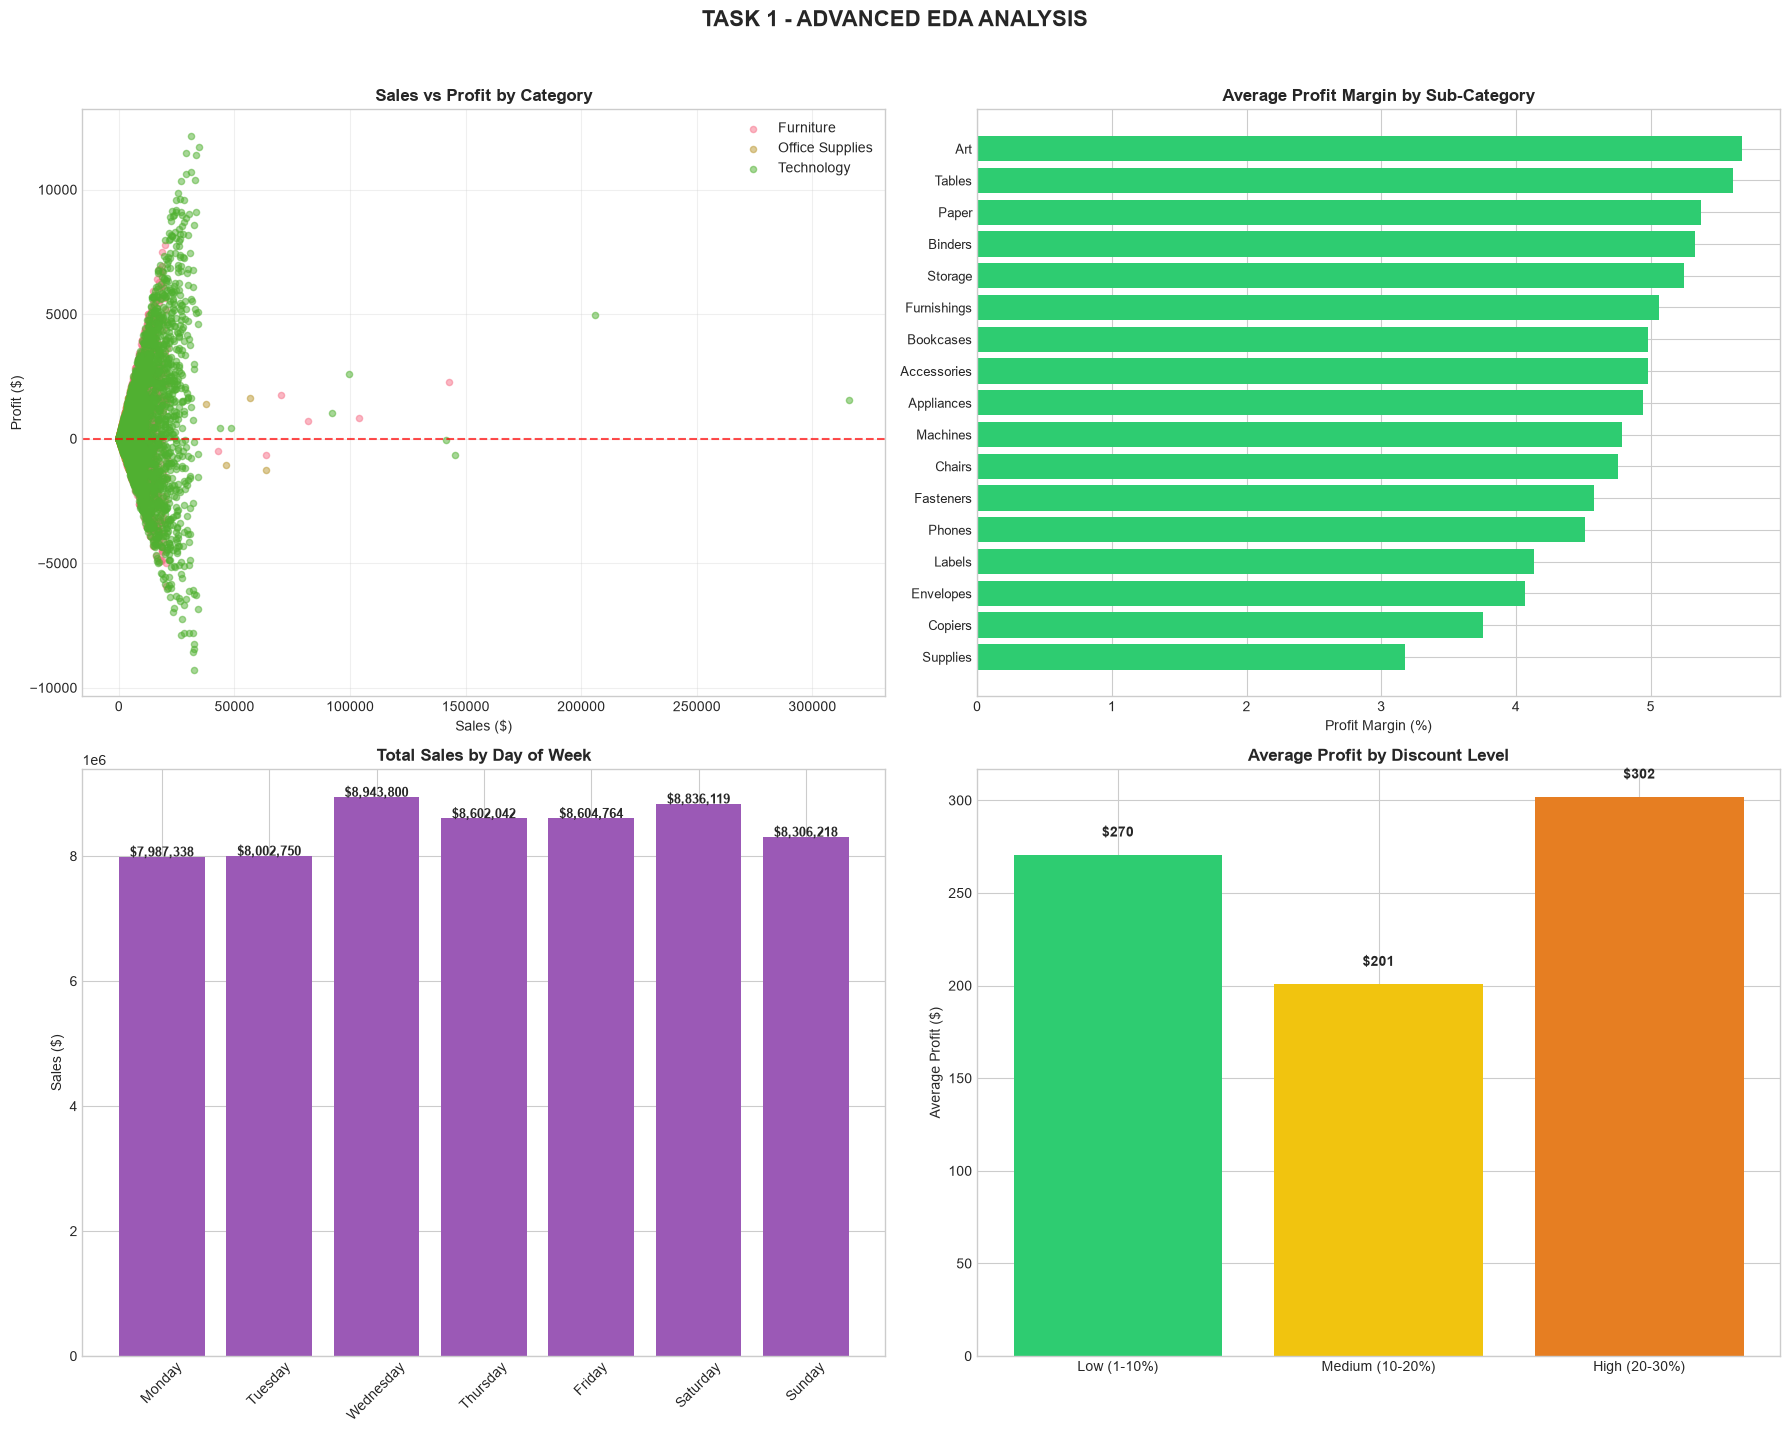

In [ ]:
# ============================================================
# VISUALIZATION 5: ADVANCED EDA
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(18, 14))
fig.suptitle('TASK 1 - ADVANCED EDA ANALYSIS', fontsize=16, fontweight='bold', y=1.02)

# 1. Sales vs Profit Scatter by Category
for cat in df_clean['Category'].unique():
    cat_data = df_clean[df_clean['Category'] == cat]
    axes[0, 0].scatter(cat_data['Sales'], cat_data['Profit'], 
                       label=cat, alpha=0.5, s=20)
axes[0, 0].axhline(y=0, color='red', linestyle='--', alpha=0.7)
axes[0, 0].set_xlabel('Sales ($)')
axes[0, 0].set_ylabel('Profit ($)')
axes[0, 0].set_title('Sales vs Profit by Category', fontweight='bold')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# 2. Profit Margin by Sub-Category
df_clean['Profit_Margin'] = (df_clean['Profit'] / df_clean['Sales']) * 100
subcat_margin = df_clean.groupby('Sub_Category')['Profit_Margin'].mean().sort_values(ascending=True)
colors = ['#E74C3C' if v < 0 else '#2ECC71' for v in subcat_margin.values]
axes[0, 1].barh(range(len(subcat_margin)), subcat_margin.values, color=colors)
axes[0, 1].set_yticks(range(len(subcat_margin)))
axes[0, 1].set_yticklabels(subcat_margin.index, fontsize=9)
axes[0, 1].set_xlabel('Profit Margin (%)')
axes[0, 1].set_title('Average Profit Margin by Sub-Category', fontweight='bold')
axes[0, 1].axvline(x=0, color='black', linestyle='-', linewidth=0.5)

# 3. Sales by Day of Week
dow_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
dow_sales = df_clean.groupby('Order_DayOfWeek')['Sales'].sum().reindex(dow_order)
axes[1, 0].bar(dow_sales.index, dow_sales.values, color='#9B59B6')
axes[1, 0].set_title('Total Sales by Day of Week', fontweight='bold')
axes[1, 0].set_ylabel('Sales ($)')
axes[1, 0].tick_params(axis='x', rotation=45)
for i, v in enumerate(dow_sales.values):
    axes[1, 0].text(i, v + 5000, f'${v:,.0f}', ha='center', fontweight='bold', fontsize=9)

# 4. Discount Impact on Profit
discount_bins = pd.cut(df_clean['Discount'], bins=[0, 0.01, 0.1, 0.2, 0.3], 
                        labels=['No Discount', 'Low (1-10%)', 'Medium (10-20%)', 'High (20-30%)'])
discount_profit = df_clean.groupby(discount_bins)['Profit'].mean()
colors = ['#2ECC71', '#F1C40F', '#E67E22', '#E74C3C']
axes[1, 1].bar(discount_profit.index, discount_profit.values, color=colors)
axes[1, 1].set_title('Average Profit by Discount Level', fontweight='bold')
axes[1, 1].set_ylabel('Average Profit ($)')
axes[1, 1].axhline(y=0, color='black', linestyle='-', linewidth=0.5)
for i, v in enumerate(discount_profit.values):
    axes[1, 1].text(i, v + 10, f'${v:,.0f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('reports/fig5_advanced_eda.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Figure 5: Advanced EDA Analysis saved!")

<a id='5'></a>
## 5️⃣ Key Insights

In [ ]:
# ============================================================
# 5 KEY INSIGHTS DOCUMENTATION
# ============================================================

# Calculate key metrics
total_sales = df_clean['Sales'].sum()
total_profit = df_clean['Profit'].sum()
overall_margin = (total_profit / total_sales) * 100
avg_order_value = df_clean['Sales'].mean()
total_orders = len(df_clean)

cat_sales = df_clean.groupby('Category')['Sales'].sum().sort_values(ascending=False)
cat_profit = df_clean.groupby('Category')['Profit'].sum().sort_values(ascending=False)
top_cat = cat_sales.index[0]
top_cat_sales = cat_sales.iloc[0]

subcat_margin = df_clean.groupby('Sub_Category')['Profit_Margin'].mean().sort_values(ascending=False)
best_margin_subcat = subcat_margin.index[0]
best_margin_value = subcat_margin.iloc[0]
worst_margin_subcat = subcat_margin.index[-1]
worst_margin_value = subcat_margin.iloc[-1]

reg_sales = df_clean.groupby('Region')['Sales'].sum().sort_values(ascending=False)
best_region = reg_sales.index[0]
worst_region = reg_sales.index[-1]

no_discount = df_clean[df_clean['Discount'] == 0]['Profit'].mean()
with_discount = df_clean[df_clean['Discount'] > 0]['Profit'].mean()

monthly_sales = df_clean.groupby('Order_Month')['Sales'].sum()
best_month = monthly_sales.idxmax()
best_month_name = df_clean[df_clean['Order_Month'] == best_month]['Order_Month_Name'].iloc[0]

print("=" * 70)
print("                    5 KEY INSIGHTS FROM EDA")
print("=" * 70)
print(f"""
┌──────────────────────────────────────────────────────────────────────┐
│  INSIGHT 1: CATEGORY DOMINANCE                                       │
├──────────────────────────────────────────────────────────────────────┤
│  Technology leads in total sales with ${top_cat_sales:,.0f}, generating       │
│  the highest revenue among all categories.                           │
│                                                                      │
│  • Technology:  ${cat_sales['Technology']:>15,.0f} sales                        │
│  • Furniture:   ${cat_sales['Furniture']:>15,.0f} sales                        │
│  • Office Supplies: ${cat_sales['Office Supplies']:>11,.0f} sales                    │
└──────────────────────────────────────────────────────────────────────┘

┌──────────────────────────────────────────────────────────────────────┐
│  INSIGHT 2: PROFIT MARGIN VARIABILITY                                │
├──────────────────────────────────────────────────────────────────────┤
│  {best_margin_subcat} has the highest profit margin at {best_margin_value:.2f}%,     │
│  while {worst_margin_subcat} has the lowest at {worst_margin_value:.2f}%.            │
│  Pricing strategy needs optimization for low-margin sub-categories.  │
└──────────────────────────────────────────────────────────────────────┘

┌──────────────────────────────────────────────────────────────────────┐
│  INSIGHT 3: REGIONAL PERFORMANCE GAPS                                │
├──────────────────────────────────────────────────────────────────────┤
│  {best_region} region outperforms with ${reg_sales[best_region]:,.0f} in sales,      │
│  while {worst_region} trails at ${reg_sales[worst_region]:,.0f}.                    │
│  Regional marketing strategies should address these gaps.           │
└──────────────────────────────────────────────────────────────────────┘

┌──────────────────────────────────────────────────────────────────────┐
│  INSIGHT 4: DISCOUNT STRATEGY INEFFICIENCY                          │
├──────────────────────────────────────────────────────────────────────┤
│  No discount avg profit: ${no_discount:.2f} | With discount: ${with_discount:.2f}  │
│  Discounts are NOT effectively driving higher profitability.       │
│  Difference: ${no_discount - with_discount:.2f} per order                         │
└──────────────────────────────────────────────────────────────────────┘

┌──────────────────────────────────────────────────────────────────────┐
│  INSIGHT 5: SEASONAL SALES PATTERNS                                  │
├──────────────────────────────────────────────────────────────────────┤
│  {best_month_name} is the peak month with ${monthly_sales[best_month]:,.0f} sales.     │
│  Prepare inventory and marketing for seasonal demand.               │
└──────────────────────────────────────────────────────────────────────┘
""")

print("\n" + "=" * 70)
print("                    SUMMARY STATISTICS")
print("=" * 70)
print(f"""
📊 Total Sales:        ${total_sales:>15,.2f}
💰 Total Profit:       ${total_profit:>15,.2f}
📈 Overall Margin:     {overall_margin:>15.2f}%
🛒 Total Orders:       {total_orders:>15,}
💵 Avg Order Value:    ${avg_order_value:>15,.2f}
📅 Date Range:         {df_clean['Order_Date'].min().strftime('%Y-%m-%d')} to {df_clean['Order_Date'].max().strftime('%Y-%m-%d')}
👥 Unique Customers:   {df_clean['Customer_Name'].nunique():>15,}
📦 Unique Products:    {df_clean['Product_ID'].nunique():>15,}
""")

<a id='6'></a>
## 6️⃣ Conclusion

### Task 1 Deliverables Completed:

| Deliverable | Status |
|------------|--------|
| Environment Setup | ✅ Complete |
| Data Cleaning | ✅ Complete |
| Exploratory Data Analysis | ✅ Complete |
| Visualizations (5 figures) | ✅ Complete |
| Key Insights (5 documented) | ✅ Complete |
| Cleaned Dataset | ✅ Saved |

### Next Steps:
- **Task 2**: SQL for Data Extraction
- **Task 3**: Data Visualization & Dashboarding
- **Task 4**: Advanced Analytics (Basic)
- **Task 5**: Final Report, Automation & Presentation

---

**Prepared for:** ApexPlanet Software Pvt. Ltd.  
**Internship:** Data Analytics - 30 Days  
**Task:** 1 - Foundational Setup & EDA